# <b>Data-Driven Player Grouping in Cricket using Machine Learning</b>

This project applies unsupervised machine learning technique i.e <b>Clustering Algorithm</b>:
- K Means Clustering
- Hierarchical Clustering (Agglomerative Clustering)

to cluster cricket players based on their batting performance. Using the `Cricket.csv` dataset, which contains statistics such as matches played, runs, batting average, and strike rate, we focus on two key features—Average (Ave) and Strike Rate (SR)—to group players into meaningful categories.

After basic data cleaning and feature scaling, we implement K-Means clustering (K=4) and Hierarchical Clustering to analyze player similarities. 

Box plots are also used to visualize and interpret the distribution of clusters. 

Additionally, helper functions are created to check whether two players belong to the same cluster (check_cluster) and to identify the cluster ID of a specific player (cluster_id).

---

## STEPS INVOLVED :
1. READ AND UNDERSTAND THE DATA
2. DATA CLEANING
3. DATA PREPARATION
4. CLUSTERING TENDENCY 
5. K MEANS CLUSTERING
   - cluster analysis and some user defined functions to explore the clusters
6. HIERARCHICAL CLUSTERING
   - used single, complete, average and ward's linkage
   - cluster analysis for hierarchical clustering
7. SUMMARY

---

# STEP 1: Reading and Understanding the data 

In [1]:
import warnings as warnings 
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd 
import numpy as np 

In [3]:
# read the data 
cricket_df = pd.read_csv('Cricket.csv', encoding = 'latin1')
cricket_df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


In [4]:
# understand the data 
cricket_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [5]:
# checking nulls 
cricket_df.isnull().sum()

Player    0
Span      0
Mat       0
Inns      0
NO        0
Runs      0
HS        0
Ave       0
BF        0
SR        0
100       0
50        0
0         0
dtype: int64

In [6]:
# checking number of rows and columns 
cricket_df.shape

(79, 13)

In [7]:
# column names
cricket_df.columns

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0'],
      dtype='object')

In [8]:
# statistical analysis of numerical vars 
cricket_df.describe()

,Mat,Inns,NO,Runs,Ave,BF,SR,100,50,0
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,245.075949,230.544304,30.037975,7618.139241,38.523291,9684.455696,79.295316,11.556962,46.443038,13.253165
std,74.211716,70.321022,14.421710,2551.873313,5.919093,3193.835825,9.925307,8.092014,16.351701,5.925755
min,128.000000,127.000000,4.000000,5080.000000,23.570000,5504.000000,60.570000,0.000000,23.000000,3.000000
25%,188.000000,177.000000,17.500000,5759.000000,34.600000,7393.500000,73.725000,6.000000,34.500000,9.000000
50%,232.000000,217.000000,29.000000,6798.000000,37.870000,9134.000000,77.730000,10.000000,42.000000,13.000000
75%,281.500000,261.500000,40.000000,8739.500000,41.845000,10976.000000,85.180000,15.500000,54.000000,16.000000
max,463.000000,452.000000,70.000000,18426.000000,53.940000,21367.000000,117.000000,49.000000,96.000000,34.000000


# STEP 2: DATA CLEANING 

In [9]:
# convert the span into total years played 
cricket_df[['start', 'end']] = cricket_df['Span'].str.split('-', expand = True)
cricket_df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015


In [10]:
# convert dtpe to int 
cricket_df['start'] = cricket_df['start'].astype(int)
cricket_df['end'] = cricket_df['end'].astype(int)

In [11]:
# create a new column to compute the total years 
cricket_df['total_years'] = cricket_df['end'] - cricket_df['start'] + 1
cricket_df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,24
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,16
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,18
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,23
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,18


In [12]:
# drop redundant column span 
cricket_df = cricket_df.drop('Span', axis = 1)
cricket_df.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,SR Tendulkar (INDIA),463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,24
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,16
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,18
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,23
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,18


In [13]:
# covert HS to int 
print(cricket_df[cricket_df['HS'].str.contains('DNB', case = False, na = False)])

Empty DataFrame
Columns: [Player, Mat, Inns, NO, Runs, HS, Ave, BF, SR, 100, 50, 0, start, end, total_years]
Index: []


In [14]:
print(cricket_df[cricket_df['HS'].str.contains('TDNB', case = False, na = False)])

Empty DataFrame
Columns: [Player, Mat, Inns, NO, Runs, HS, Ave, BF, SR, 100, 50, 0, start, end, total_years]
Index: []


In [15]:
# convert HS to int dtype 
cricket_df['HS'] = cricket_df['HS'].str.replace('*', '', regex = False)
cricket_df['HS'] = cricket_df['HS'].astype(int)

In [16]:
cricket_df.head()

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,24
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,16
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,18
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,23
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,18


In [17]:
# check the data types of the columns 
cricket_df.dtypes

Player          object
Mat              int64
Inns             int64
NO               int64
Runs             int64
HS               int32
Ave            float64
BF               int64
SR             float64
100              int64
50               int64
0                int64
start            int32
end              int32
total_years      int32
dtype: object

# STEP 3: DATA PREPARATION

In [18]:
# data preparation : feature scaling 
from sklearn.preprocessing import StandardScaler

In [19]:
df = cricket_df.drop('Player', axis=1)
df.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,24
1,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,16
2,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,18
3,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,23
4,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,18


In [20]:
# create object 
scaler = StandardScaler()

# fit and transform the data keeping mean= 0 and std dev= 1
cricket_df_scaled = scaler.fit_transform(df)

cricket_df_scaled

array([[ 2.95528204,  3.1693334 ,  0.76496275, ..., -0.67030765,
         0.46828112,  2.81278702],
       [ 2.15517925,  2.13891509,  0.76496275, ...,  0.62126074,
         0.86464763,  0.38093832],
       [ 1.76190839,  1.92424461,  0.6253968 , ...,  0.0341842 ,
         0.46828112,  0.9889005 ],
       ...,
       [-0.65196103, -0.70904664,  0.48583085, ...,  0.73867605,
         0.33615894, -1.13896711],
       [-0.63839997, -0.99527395,  0.20669894, ...,  0.38643013,
         0.0719146 , -0.83498602],
       [ 0.27019133, -0.03641246,  1.88149036, ...,  0.15159951,
         0.33615894,  0.38093832]])

In [21]:
df.columns

Index(['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0',
       'start', 'end', 'total_years'],
      dtype='object')

In [22]:
cricket_df_scaled = pd.DataFrame(cricket_df_scaled, columns = ['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0',
       'start', 'end', 'total_years'])
cricket_df_scaled.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,-0.670308,0.468281,2.812787
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.621261,0.864648,0.380938
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.034184,0.468281,0.988900
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,-0.670308,0.336159,2.508806
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.386430,0.864648,0.988900


In [23]:
cricket_df_scaled.describe()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
count,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01,7.900000e+01
mean,-5.551115e-17,-7.316581e-17,9.837419e-17,1.264811e-16,2.023698e-16,5.621382e-17,2.642050e-16,7.796155e-16,1.039956e-16,1.658308e-16,8.080737e-17,-8.797463e-15,-1.064971e-14,-1.285891e-16
std,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00,1.006390e+00
min,-1.587674e+00,-1.481860e+00,-1.817007e+00,-1.000973e+00,-1.713068e+00,-2.542423e+00,-1.317278e+00,-1.898679e+00,-1.437319e+00,-1.442837e+00,-1.741328e+00,-2.314122e+00,-2.306285e+00,-1.746929e+00
25%,-7.740106e-01,-7.662921e-01,-8.749372e-01,-7.331943e-01,-7.641007e-01,-6.670549e-01,-7.218889e-01,-5.648097e-01,-6.911098e-01,-7.350521e-01,-7.223285e-01,-6.703076e-01,-7.208184e-01,-8.349860e-01
50%,-1.773238e-01,-1.938375e-01,-7.243296e-02,-3.234407e-01,-1.689858e-01,-1.110754e-01,-1.734507e-01,-1.587174e-01,-1.936367e-01,-2.734534e-01,-4.299574e-02,1.515995e-01,3.361589e-01,7.695724e-02
75%,4.939489e-01,4.430183e-01,6.951798e-01,4.422344e-01,5.869710e-01,5.647713e-01,4.069705e-01,5.966854e-01,4.903888e-01,4.651045e-01,4.665038e-01,8.560914e-01,8.646476e-01,6.849194e-01
max,2.955282e+00,3.169333e+00,2.788669e+00,4.262328e+00,3.691219e+00,2.621216e+00,3.681214e+00,3.823117e+00,4.656726e+00,3.050057e+00,3.523501e+00,1.677999e+00,1.128892e+00,2.812787e+00


# STEP 4: CHECKING THE CLUSTERING TENDENCY OF THE DATA 

In [24]:
# check clustering tendency of the data using hopkins stats 
from pyclustertend import hopkins 

In [25]:
h = hopkins(cricket_df_scaled, cricket_df_scaled.shape[0])
print(h)

0.2866177967259416


h< 0.5 then it has good cluster tendency 

# STEP 5: K MEANS ALGORITHM 

In [26]:
# using KMeans to form clusters 
from sklearn.cluster import KMeans

In [27]:
km_model = KMeans(n_clusters = 4, max_iter = 50)
km_model.fit(cricket_df_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,50
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [28]:
print(km_model.labels_)

[1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 0 2 2 2 2 2 3 2 2 0 0 2 2 2 0 2 2 3 2 0 2 2
 0 3 3 3 2 3 2 3 3 0 3 0 0 0 3 3 3 0 3 0 0 3 0 0 0 3 0 0 0 0 3 3 0 0 3 0 3
 3 0 0 0 3]


In [29]:
cricket_df_scaled['km_cluster_id'] = km_model.labels_ 

In [30]:
cricket_df_scaled.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years,km_cluster_id
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,-0.670308,0.468281,2.812787,1
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.621261,0.864648,0.380938,1
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.034184,0.468281,0.988900,1
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,-0.670308,0.336159,2.508806,1
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.386430,0.864648,0.988900,1


In [31]:
# update the dataframe 
cricket_df_scaled['Player'] = cricket_df['Player']
cricket_df_scaled

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years,km_cluster_id,Player
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,-0.670308,0.468281,2.812787,1,SR Tendulkar (INDIA)
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.621261,0.864648,0.380938,1,KC Sangakkara (Asia/ICC/SL)
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.034184,0.468281,0.988900,1,RT Ponting (AUS/ICC)
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,-0.670308,0.336159,2.508806,1,ST Jayasuriya (Asia/SL)
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.386430,0.864648,0.988900,1,DPMD Jayawardene (Asia/SL)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,-1.587674,-1.481860,-1.188961,-0.979677,-0.522838,1.106299,-0.559768,-1.457604,-0.069268,-0.950465,-1.741328,-2.314122,-2.306285,0.684919,3,CG Greenidge (WI)
75,-1.126598,-1.167010,0.067133,-0.984410,-1.713068,0.829159,-0.863213,-0.562275,-1.437319,-0.273453,-1.231828,0.856091,0.864648,-0.227024,0,Misbah-ul-Haq (PAK)
76,-0.651961,-0.709047,0.485831,-0.996241,-0.941027,-0.537836,-0.967512,-0.234765,-0.815478,-1.258197,-1.061995,0.738676,0.336159,-1.138967,0,PD Collingwood (ENG)
77,-0.638400,-0.995274,0.206699,-0.997819,0.217035,0.208570,-1.317278,1.332823,-0.691110,-1.012011,0.296671,0.386430,0.071915,-0.834986,0,A Symonds (AUS)


### VISUALISING THE CLUSTERS USING BOXPLOT 

In [32]:
# visualise the clusters
import seaborn as sns 
import matplotlib.pyplot as plt

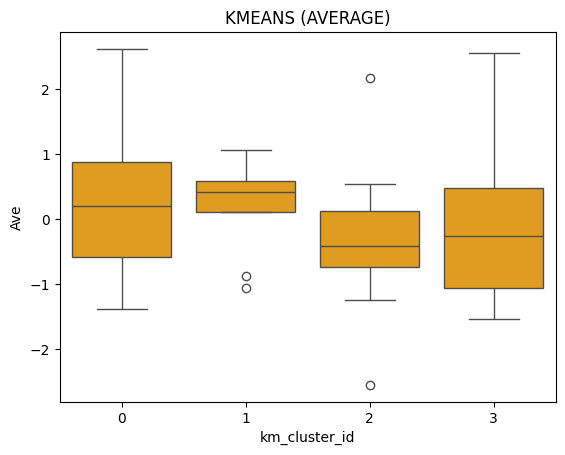

In [33]:
sns.boxplot(x='km_cluster_id', y = 'Ave', data = cricket_df_scaled, color='orange')
plt.title('KMEANS (AVERAGE)')
plt.show()

Cluster 0 → Weakest performers (lowest average scores).

Cluster 1 → Below-average performers (slightly better than cluster 0).

Cluster 2 → Average players with some stars (median low, but max very high).

Cluster 3 → Best performers overall (positive median, consistent).

Text(0.5, 1.0, 'KMEANS (SR)')

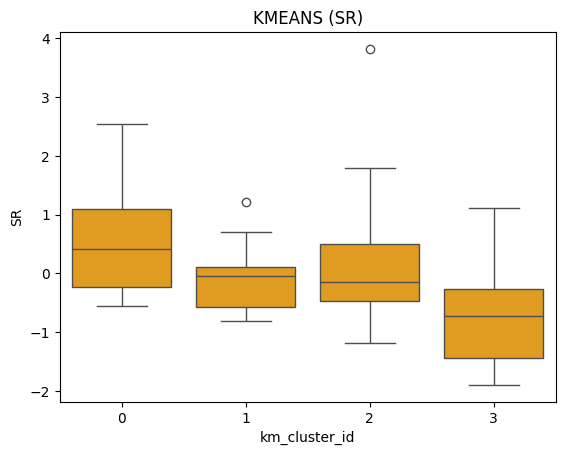

In [34]:
sns.boxplot(x= 'km_cluster_id', y='SR', data = cricket_df_scaled, color='orange')
plt.title('KMEANS (SR)')

Cluster 0 → Top performers (highest SR)

Cluster 1 → Weak performers (lowest SR)

Cluster 2 → Moderate performers (average SR, some outliers better)

Cluster 3 → Slightly below-average performers

In [35]:
# function to check if two players are in same cluster or not 
def check_cluster(df, p1 , p2): #p1 and p2 are players name

    # store the cluster id for each player 
    p1_cid =df.loc[df['Player'].str.contains(p1, case = False, na = False), 'km_cluster_id']
    p2_cid =df.loc[df['Player'].str.contains(p2, case = False, na = False), 'km_cluster_id']

    # if the player name does not exist
    if p1_cid.empty:
        return f'{p1} does not exist!!!!'
    elif p2_cid.empty:
        return f'{p2} does not exist!!!'

    # if cluster id is same for both 
    if p1_cid.values[0] == p2_cid.values[0]:
        return f"{p1} and {p2} both have same cluster id {p1_cid.values[0]}."
    else:
        return f"{p1} and {p2} both don't have same cluster id ."

In [36]:
check_cluster(cricket_df_scaled, 'PD Collingwood', 'Misbah-ul-Haq')

'PD Collingwood and Misbah-ul-Haq both have same cluster id 0.'

In [37]:
check_cluster(cricket_df_scaled, 'sr tendulkar','rt ponting' )

'sr tendulkar and rt ponting both have same cluster id 1.'

In [38]:
check_cluster(cricket_df_scaled, 'sr tendulkar','V kohli' )

"sr tendulkar and V kohli both don't have same cluster id ."

In [39]:
# function to check players cluster id 
def cluster_id(df,player):
    cid = df.loc[df['Player'].str.contains(player, case= False, na= False), 'km_cluster_id']

    if cid.empty:
        return f'{player} does not exist in the data'
    else :
        return f'The cluster id of {player} is: {cid.values[0]}'

In [40]:
cluster_id(cricket_df_scaled, 'V kohli')

'The cluster id of V kohli is: 0'

# STEP 6: Hierarchical Clustering 

In [41]:
from scipy.cluster.hierarchy import linkage 
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

In [42]:
# again do feature scaling for hierarchical clustering 
df.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,463,452,41,18426,200,44.83,21367,86.23,49,96,20,1989,2012,24
1,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,16
2,375,365,39,13704,164,42.03,17046,80.39,30,82,20,1995,2012,18
3,445,433,18,13430,189,32.36,14725,91.20,28,68,34,1989,2011,23
4,448,418,39,12650,144,33.37,16020,78.96,19,77,28,1998,2015,18


In [43]:
scaler2 = StandardScaler()
hc_df = scaler2.fit_transform(df)
hc_df

array([[ 2.95528204,  3.1693334 ,  0.76496275, ..., -0.67030765,
         0.46828112,  2.81278702],
       [ 2.15517925,  2.13891509,  0.76496275, ...,  0.62126074,
         0.86464763,  0.38093832],
       [ 1.76190839,  1.92424461,  0.6253968 , ...,  0.0341842 ,
         0.46828112,  0.9889005 ],
       ...,
       [-0.65196103, -0.70904664,  0.48583085, ...,  0.73867605,
         0.33615894, -1.13896711],
       [-0.63839997, -0.99527395,  0.20669894, ...,  0.38643013,
         0.0719146 , -0.83498602],
       [ 0.27019133, -0.03641246,  1.88149036, ...,  0.15159951,
         0.33615894,  0.38093832]])

In [44]:
hc_df_scaled = pd.DataFrame(hc_df)
hc_df_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,-0.670308,0.468281,2.812787
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.621261,0.864648,0.380938
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.034184,0.468281,0.988900
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,-0.670308,0.336159,2.508806
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.386430,0.864648,0.988900


In [45]:
df.columns

Index(['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0',
       'start', 'end', 'total_years'],
      dtype='object')

In [46]:
hc_df_scaled.columns = ['Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100', '50', '0',
       'start', 'end', 'total_years']

In [47]:
hc_df_scaled.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,-0.670308,0.468281,2.812787
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.621261,0.864648,0.380938
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.034184,0.468281,0.988900
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,-0.670308,0.336159,2.508806
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.386430,0.864648,0.988900


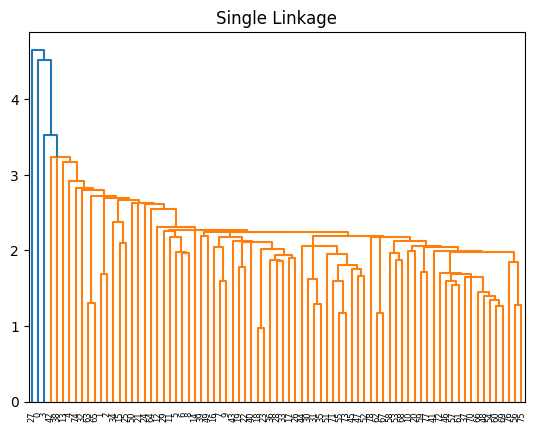

In [48]:
# first do the merging 
merging = linkage(hc_df_scaled, method = 'single', metric = 'euclidean')

# plot dendrogram 
dendrogram(merging)
plt.title('Single Linkage')
plt.show()

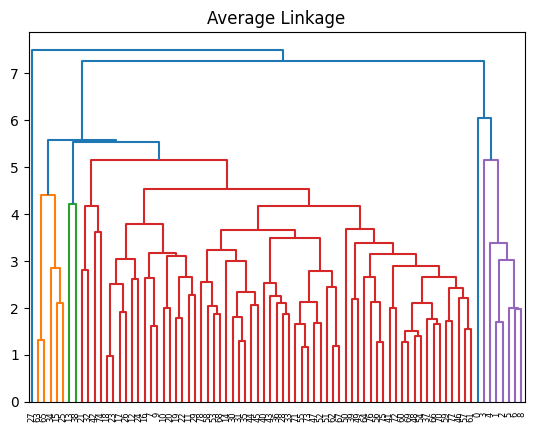

In [49]:
# try another linkage 
merging2 = linkage(hc_df_scaled , method='average', metric = 'euclidean')
dendrogram(merging2)
plt.title('Average Linkage')
plt.show()

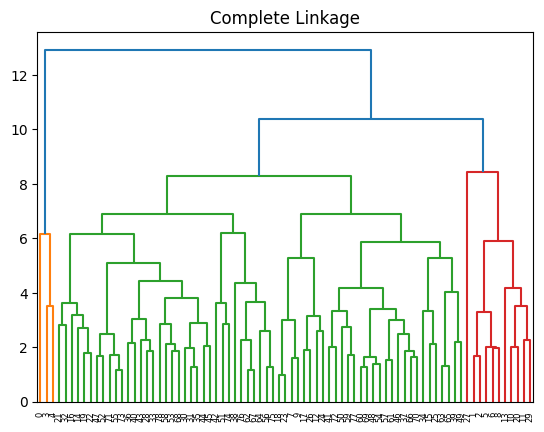

In [50]:
# try complete linkage 
merging3 = linkage(hc_df_scaled, method='complete', metric='euclidean')
dendrogram(merging3)
plt.title('Complete Linkage')
plt.show()

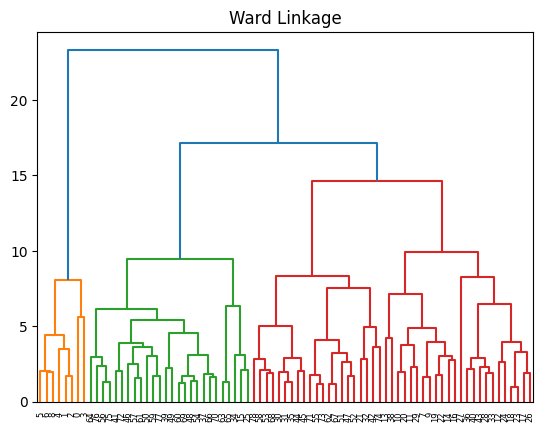

In [51]:
# try wards method too 
merging4 = linkage(hc_df_scaled, method = 'ward', metric= 'euclidean')
dendrogram(merging4)
plt.title('Ward Linkage')
plt.show()

Using ward's linkage as it has well seprated and compact clusters 

In [52]:
# cut the tree at n = 4 
cluster_hierarchy = cut_tree(merging4, n_clusters = 4)
cluster_hierarchy

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [2],
       [1],
       [1],
       [1],
       [1],
       [1],
       [3],
       [1],
       [1],
       [1],
       [2],
       [1],
       [1],
       [1],
       [1],
       [3],
       [3],
       [3],
       [1],
       [2],
       [3],
       [1],
       [2],
       [1],
       [2],
       [1],
       [2],
       [3],
       [1],
       [3],
       [3],
       [2],
       [3],
       [2],
       [2],
       [2],
       [3],
       [3],
       [3],
       [2],
       [3],
       [2],
       [2],
       [3],
       [2],
       [2],
       [2],
       [3],
       [2],
       [2],
       [2],
       [2],
       [3],
       [3],
       [2],
       [2],
       [3],
       [2],
       [3],
       [3],
       [2],
       [2],
       [2],
       [3]], dtype=int64)

In [53]:
cluster_hierarchy.shape

(79, 1)

In [54]:
cluster_hierarchy =cluster_hierarchy.reshape(-1,)

In [55]:
cluster_hierarchy.shape

(79,)

In [56]:
# add these vals to the df 
hc_df_scaled['cluster_id'] = cluster_hierarchy
hc_df_scaled['Player'] = cricket_df['Player']
hc_df_scaled.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,start,end,total_years,cluster_id,Player
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,-0.670308,0.468281,2.812787,0,SR Tendulkar (INDIA)
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.621261,0.864648,0.380938,0,KC Sangakkara (Asia/ICC/SL)
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.034184,0.468281,0.988900,0,RT Ponting (AUS/ICC)
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,-0.670308,0.336159,2.508806,0,ST Jayasuriya (Asia/SL)
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.386430,0.864648,0.988900,0,DPMD Jayawardene (Asia/SL)


Text(0.5, 1.0, 'hierarchical clustering (SR)')

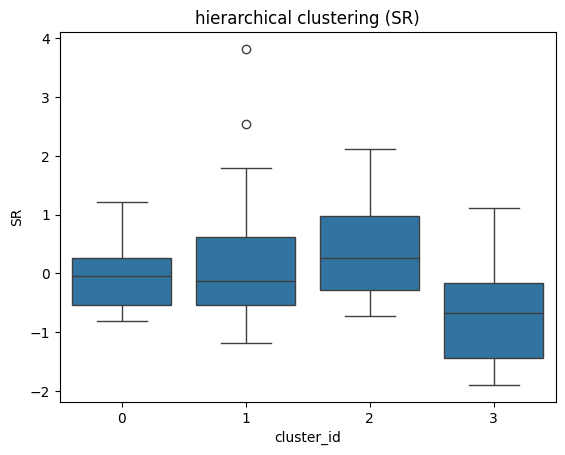

In [57]:
# analyse clusters using boxplot 
sns.boxplot(x='cluster_id', y='SR', data = hc_df_scaled)
plt.title('hierarchical clustering (SR)')

CLUSTER 0: The median is almost 0 and players in this cluster do not have high SR <br>
CLUSTER 1: The median is below 0 and the players have slightly higher SR than players in cluster 0 also there are some outliers too<br>
CLUSTER 2: The median is higher than 0 and 1 and the players have comparitively high SR among other clusters<br>
CLUSTER 3: The median is very low and has the players in this cluster have the lowest SR <br>

Text(0.5, 1.0, 'hierarchical clustering (AVERAGE)')

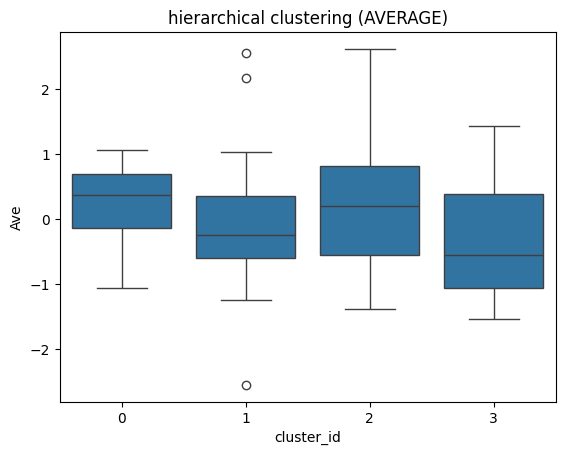

In [58]:
sns.boxplot(x= 'cluster_id', y='Ave', data= hc_df_scaled)
plt.title('hierarchical clustering (AVERAGE)')

CLUSTER 0: The median is highest among others but the players dont have much high average in this cluster<br>
CLUSTER 1: The median is low and the avearge is slightly lower than cluster 0 and also have some outliers<br>
CLUSTER 2: The median is higher than 0 and the players in this cluster have the highest average among others <br>
CLUSTER 3: The median is lowest (-ve) and the players in this cluster doesnt have a good average score among others 

# STEP 7: SUMMARY 
<b><u>K-means</u></b> appears more effective at creating distinct clusters with clear separation between player performance levels.

Strike rate clustering tends to show more extreme differentiation than average-based clustering

<b><u>Hierarchical clustering</b></u> produces more balanced but less distinct groupings

The analysis successfully segments players into different performance categories, which could be useful for team selection, player comparison, or tactical decisions